# ResNet-50 Evaluation and Visualization

In [1]:
import os
import sys

import pandas as pd
import tensorflow as tf

# Add the parent directory to the Python path to allow imports from sibling directories
sys.path.append(os.path.abspath(".."))

from data.dataset import prepare_cifar10_dataset
from models.resnet50 import ResNet50
from utils.trainer import ResNetTrainer
from utils.visualize import plot_training_hist_df, plot_confusion_matrix, plot_sample_predictions

# Check TensorFlow version and available devices
print("TensorFlow Version:", tf.__version__)
print("Devices available:", tf.config.list_physical_devices())

c:\Users\87vla\anaconda3\envs\dl_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow Version: 2.21.0
Devices available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Evaluation on CIFAR-10 dataset

In [2]:
DATASET_NAME = "cifar10"
BATCH_SIZE = 64

_, _, test_ds = prepare_cifar10_dataset(batch_size=BATCH_SIZE)
input_shape = (32, 32, 3)

print(f"\nSuccessfully loaded CIFAR-10 data pipelines.")

CIFAR-10 Shapes: (50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)

Successfully loaded CIFAR-10 data pipelines.


In [3]:
# Paths for saved model and weights
BEST_MODEL_PATH_CIF = f"../saved_models/resnet50_{DATASET_NAME}_best_model.keras"

# Option A: Load full saved model (.keras)
if os.path.exists(BEST_MODEL_PATH_CIF):
    model = tf.keras.models.load_model(BEST_MODEL_PATH_CIF)
    print("Best model loaded successfully.")
else:
    raise FileNotFoundError("No saved model or weights found. Please train the model first.")

Best model loaded successfully.


In [4]:
# Display network architecture summary
model.summary()

Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 38, 38, 3) │          0 │ sequential[0][0]  │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 38, 38,    │      1,792 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 38, 38,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 38, 38,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 38, 38,    │      4,160 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 38, 38,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 38, 38,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 38, 38,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 38, 38,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 38, 38,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 38, 38,    │     16,640 │ activation_2[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 38, 38,    │     16,640 │ activation[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 38, 38,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 38, 38,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 38, 38,    │          0 │ batch_normalizat

 Total params: 47,270,805 (180.32 MB)

 Trainable params: 23,608,842 (90.06 MB)

 Non-trainable params: 53,120 (207.50 KB)

 Optimizer params: 23,608,843 (90.06 MB)

Training history loaded successfully.


,epoch,accuracy,loss,top_2_accuracy,val_accuracy,val_loss,val_top_2_accuracy
0,0,0.252022,3.312859,0.429533,0.3792,2.268433,0.5814
1,1,0.390733,1.762548,0.606133,0.4580,1.497358,0.6782
2,2,0.440311,1.553750,0.654822,0.4728,1.532007,0.6850
3,3,0.475822,1.457075,0.686111,0.5108,1.367579,0.7220
4,4,0.500578,1.383080,0.709733,0.5238,1.390632,0.7336


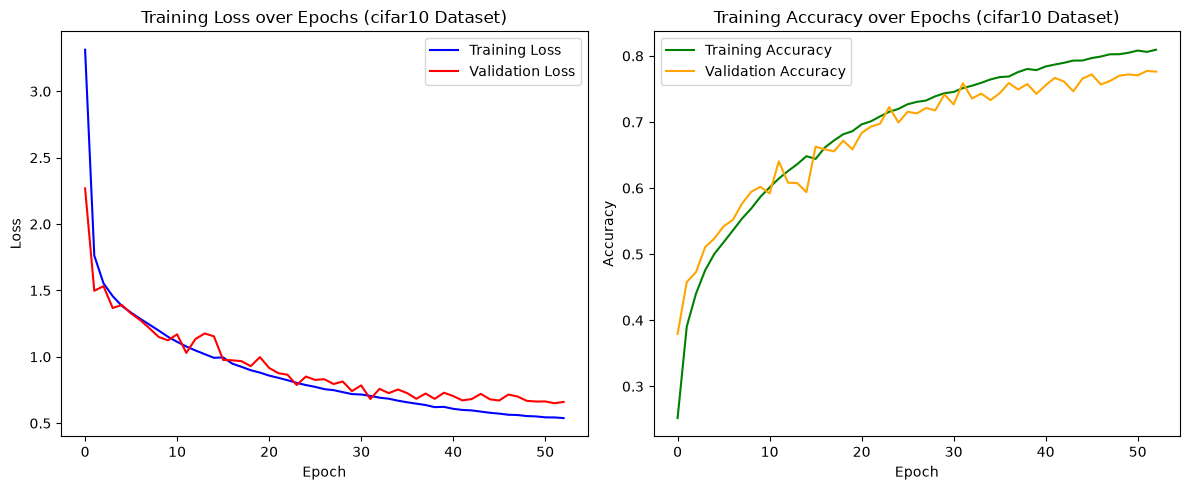

In [5]:
HISTORY_PATH = f"../saved_models/resnet50_{DATASET_NAME}_history.csv"

if os.path.exists(HISTORY_PATH):
    # Load history from CSV file into a Pandas DataFrame
    history_df = pd.read_csv(HISTORY_PATH)
    print("Training history loaded successfully.")
    display(history_df.head())
else:
    raise FileNotFoundError(f"History file not found at: {HISTORY_PATH}")

# Plot training & validation loss and accuracy curves across epochs
plot_training_hist_df(history_df, dataset_name=DATASET_NAME)

In [6]:
trainer = ResNetTrainer(model=model)

# Evaluate model performance on unseen test data
results = trainer.evaluate(test_ds, dataset_name=DATASET_NAME)

print(f"Test Accuracy ({DATASET_NAME.upper()}): {results['accuracy'] * 100:.2f}%")
print(f"Test Loss ({DATASET_NAME.upper()}): {results['loss']:.4f}")

--- Evaluating ResNet-5 on (cifar10) Test Data ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.7580 - loss: 0.7342 - top_2_accuracy: 0.8936
Test Accuracy (CIFAR10): 75.80%
Test Loss (CIFAR10): 0.7342


157/157 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step


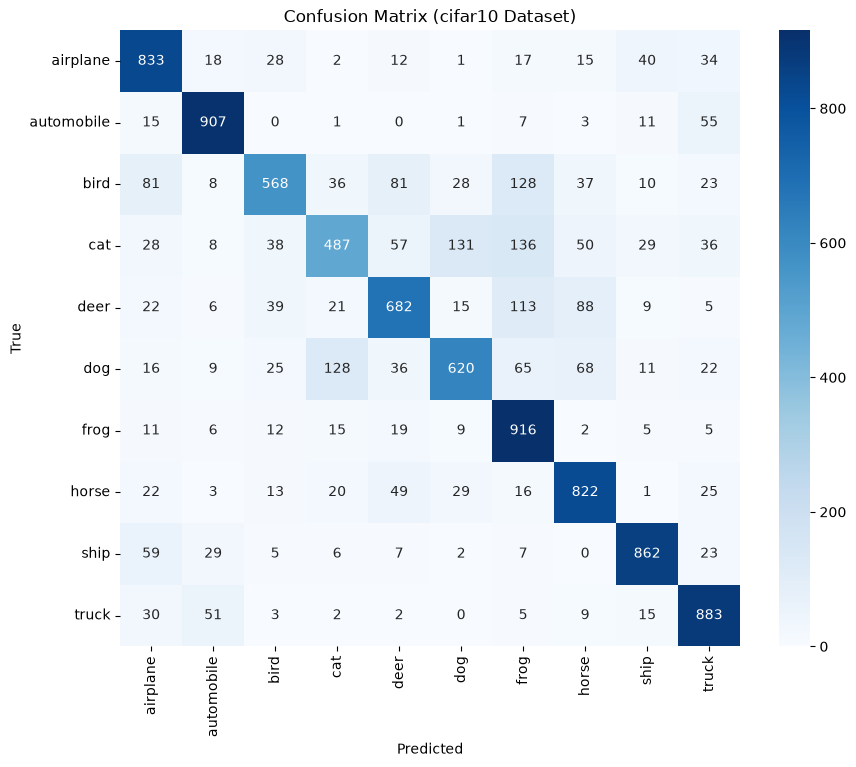

In [7]:
# Generate and display normalized confusion matrix heatmap
plot_confusion_matrix(model=model, dataset=test_ds, dataset_name=DATASET_NAME)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


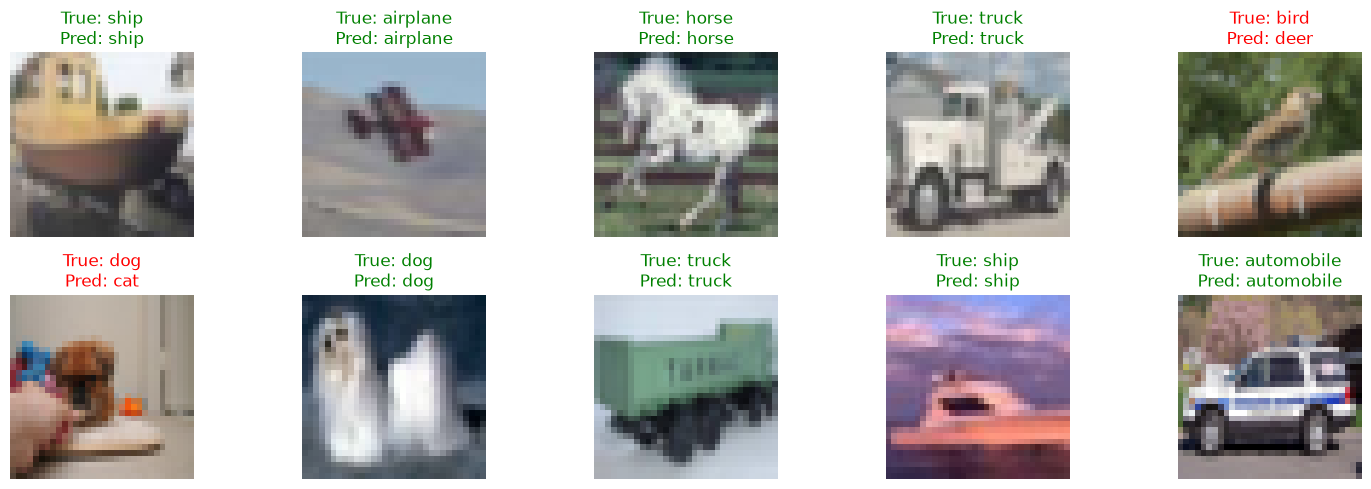

In [8]:
# Visualize random test set samples with green/red prediction status labels
plot_sample_predictions(
    model=model,
    dataset=test_ds,
    dataset_name=DATASET_NAME,
    num_samples=10
)